# Politecnico Malvinas Argentina - Procesamiento del Habla
## Comparación de modelos de procesamiento del lenguaje

En esta sección se propone aplicar distintos tipos de modelos sobre el mismo dataset, con el objetivo de comparar su comportamiento y analizar sus diferencias.

Se trabajará con tres enfoques:

- Modelos secuenciales (RNN / LSTM)
- Modelos Seq2Seq
- Modelos basados en transformers

El objetivo es observar cómo evoluciona la capacidad del modelo para representar y comprender el lenguaje, así como analizar sus limitaciones en cada caso.

In [ ]:
import pandas as pd

df = pd.read_table('/content/reviews_filmaffinity.csv', sep=r'\|\|', header=0, engine='python')
df.sample(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text
5393,Volver,Drama,"7,1",8.0,"Volver, para cerrar el círculo",Esta película es Volver de muchas formas. Es p...
3401,Alatriste,Aventuras,"5,5",7.0,Feliz desventura,La película se olvida de la aventura y el ritm...
493,Lo imposible,Drama,"6,8",9.0,LO IMPOSIBLE SERÁ OLVIDARTE DE ELLA,Reconozco que fui al cine predispuesta a que m...
2076,Ágora,Aventuras,"6,5",5.0,Mejor en la gran pantalla,Aunque a mucha gente llegue a gustarle verdade...
7211,Los crímenes de Oxford,Intriga,"5,7",7.0,Alex es Alex,"Siguiendo su linea, Alex de la Iglesia nos vue..."


# MODELO SECUENCIAL (LSTM)
## Modelo 1: redes neuronales secuenciales (LSTM)

En este modelo se utilizará una arquitectura secuencial que procesa el texto palabra por palabra, capturando información del contexto mediante estados internos.

Este tipo de modelo permite superar algunas limitaciones de los enfoques tradicionales, incorporando noción de orden en el lenguaje.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenización
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['review_text'])

X_seq = tokenizer.texts_to_sequences(df['review_text'])
X_pad = pad_sequences(X_seq, maxlen=100)

# Labels
y_bin = df['review_rate'].apply(lambda x: 1 if x > 5 else 0)

# Modelo
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_lstm.fit(X_pad, y_bin, epochs=3, batch_size=32)

Epoch 1/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.6838 - loss: 0.5879
Epoch 2/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.8124 - loss: 0.4081
Epoch 3/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.8678 - loss: 0.3272


- ¿Mejora respecto a TF-IDF?
- ¿captura mejor el contexto?-

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


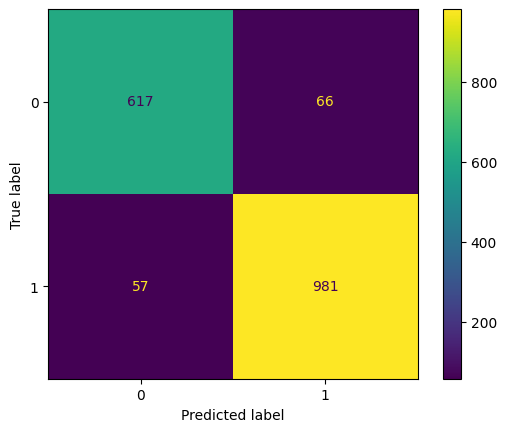

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_bin, test_size=0.2, random_state=42)

# Make predictions on the test set
y_pred_proba = model_lstm.predict(X_test)
y_pred = np.where(y_pred_proba > 0.5, 1, 0)

# Calculate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


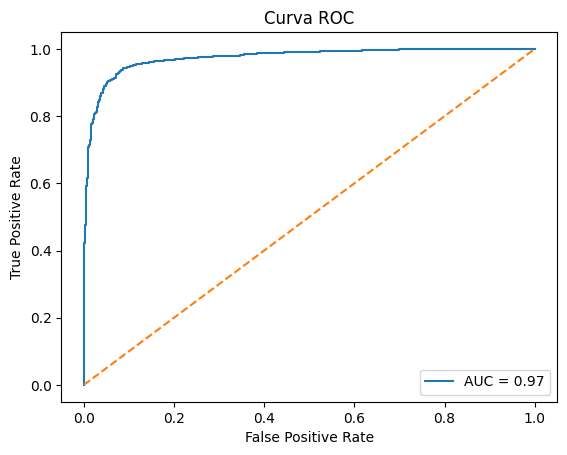

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test is already binary, no need to convert
y_test_roc = y_test

# probabilidades
y_proba = model_lstm.predict(X_test)

# curva
fpr, tpr, thresholds = roc_curve(y_test_roc, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

#MODELO SEQ2SEQ
## Modelo 2: arquitectura Seq2Seq

Los modelos Seq2Seq permiten transformar una secuencia en otra. En el contexto del lenguaje, pueden utilizarse para tareas como generación de texto o reformulación.

En esta actividad se utilizará un enfoque simplificado para analizar cómo el modelo representa secuencias completas.

In [ ]:
# Ejemplo conceptual: encoder simple
from tensorflow.keras.layers import GRU

model_seq = Sequential([
    Embedding(5000, 64),
    GRU(64),
    Dense(1, activation='sigmoid')
])

In [ ]:
# Predicciones (probabilidades)
y_proba = model_seq.predict(X_test)

# Convertir a clases (umbral 0.5)
y_pred = (y_proba > 0.5).astype(int)

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall (Sensibilidad):", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nReporte completo:")
print(classification_report(y_test, y_pred))

Accuracy: 0.49564206856478793
Precision: 0.5974770642201835
Recall (Sensibilidad): 0.5019267822736031
F1-score: 0.5455497382198953

Reporte completo:
              precision    recall  f1-score   support

           0       0.39      0.49      0.43       683
           1       0.60      0.50      0.55      1038

    accuracy                           0.50      1721
   macro avg       0.49      0.49      0.49      1721
weighted avg       0.52      0.50      0.50      1721



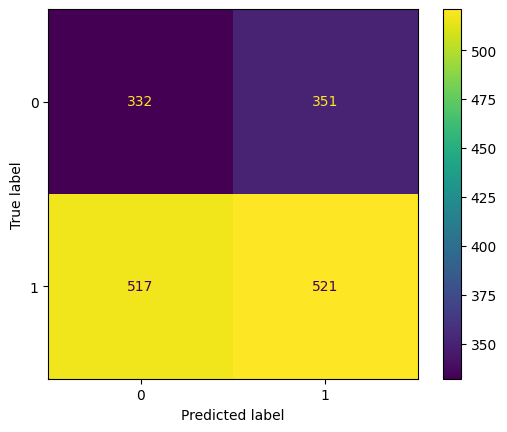

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

- ¿Dónde se equivoca más?
- ¿Hay más falsos positivos o falsos negativos?

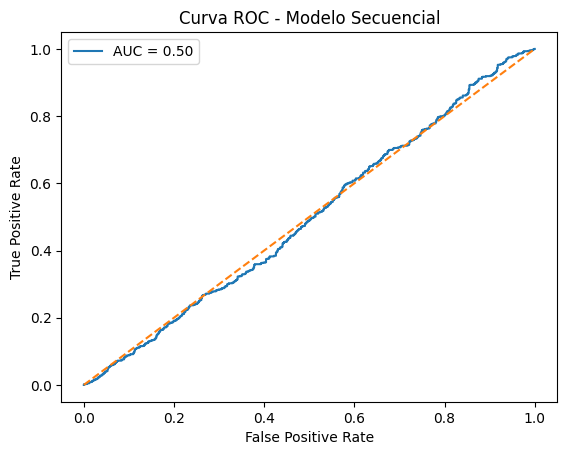

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Secuencial")
plt.legend()
plt.show()

In [ ]:
classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
#APLICAR AL CONJUNTO DE TEST
predicciones = classifier(
    df['review_text'].loc[y_test.index].tolist(),
    truncation=True,
    batch_size=16
)

KeyboardInterrupt: 

In [ ]:
predicciones = classifier(
    df['review_text'].loc[y_test.index].tolist(),
    truncation=True,
    batch_size=16
)

KeyboardInterrupt: 

In [ ]:
X_test_small = df['review_text'].loc[y_test.index][:200]

predicciones = classifier(X_test_small.tolist(), truncation=True, batch_size=16)

In [ ]:
#CONVERTIR SALIDA A NÚMEROS
y_pred = []
y_proba = []

for p in predicciones:
    if p['label'] == 'POSITIVE':
        y_pred.append(1)
        y_proba.append(p['score'])
    else:
        y_pred.append(0)
        y_proba.append(1 - p['score'])

NameError: name 'predicciones' is not defined

In [ ]:
#PREPARAR y_test
y_test_bin = y_test.map({'negativo': 0, 'positivo': 1})

In [ ]:
#MÉTRICAS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("Precision:", precision_score(y_test_bin, y_pred))
print("Recall:", recall_score(y_test_bin, y_pred))
print("F1:", f1_score(y_test_bin, y_pred))

print("\nReporte completo:")
print(classification_report(y_test_bin, y_pred))

In [ ]:
#MATRIZ DE CONFUSIÓN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_bin, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
#CURVA ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Transformer")
plt.legend()
plt.show()